SE: 7x4 -> on (3,2)
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


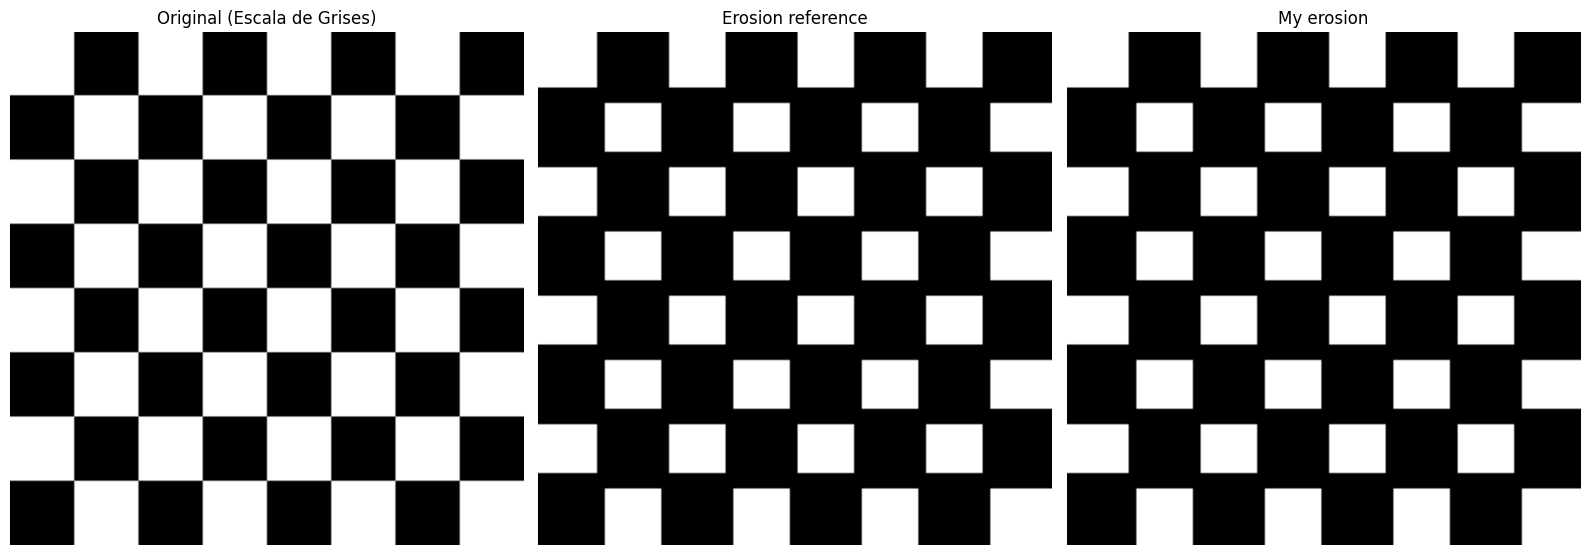

In [58]:
from skimage import data
from skimage import morphology
import matplotlib.pyplot as plt
import numpy as np

def erosion(img,se):
    width, height = img.shape
    se_width, se_height = se.shape
    cx, cy = se_width // 2, se_height // 2 # aproximate center if no point was given for the SE

    print(f'SE: {se_width}x{se_height} -> on ({cx},{cy})')

    # Padding
    pad_top = cx
    pad_bottom = se_width - 1 - cx
    pad_left = cy
    pad_right = se_height - 1 - cy
    
    padded_img = np.pad(img, ((pad_top, pad_bottom), (pad_left, pad_right)), constant_values=1)

    result_img = np.zeros_like(img)
    print(padded_img)

    for x in range(width):
        for y in range(height):
            mask = padded_img[x : x + se_width, y : y + se_height]
            
            # Filtramos solo donde el SE vale 1 y sacamos el mínimo
            masked_img = mask[se == 1]
            
            result_img[x, y] = np.min(masked_img) #basta con que un pixel del se no este incluido (que donde decia 1 en el SE sea 0 en la imagen)
    return result_img


img = data.checkerboard()
img = (img > 128).astype(np.uint8)
#img = np.array([
#    [ 1, 1, 1, 1],
#    [ 1, 1, 1, 1],
#    [ 1, 0, 0, 1],
#    [ 1, 1, 1, 1]
#])

structuring_element = np.array([
    [ 1, 1, 1],
    [ 1, 1, 1],
    [ 1, 1, 1]
])
structuring_element = np.array([
    [ 1, 1, 1, 1],
    [ 1, 0, 0, 1],
    [ 1, 0, 0, 1],
    [ 1, 1, 1, 1],
    [ 1, 1, 1, 1],
    [ 1, 1, 1, 1],
    [ 1, 1, 1, 1],
])

my_erosion = erosion(img,structuring_element)

img_erosion = morphology.erosion(img, structuring_element)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original (Escala de Grises)')
axes[0].axis('off')

axes[1].imshow(img_erosion, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Erosion reference')
axes[1].axis('off')

axes[2].imshow(my_erosion, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('My erosion')
axes[2].axis('off')

plt.tight_layout()
plt.show()


SE: 7x4 -> on (3,2)
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


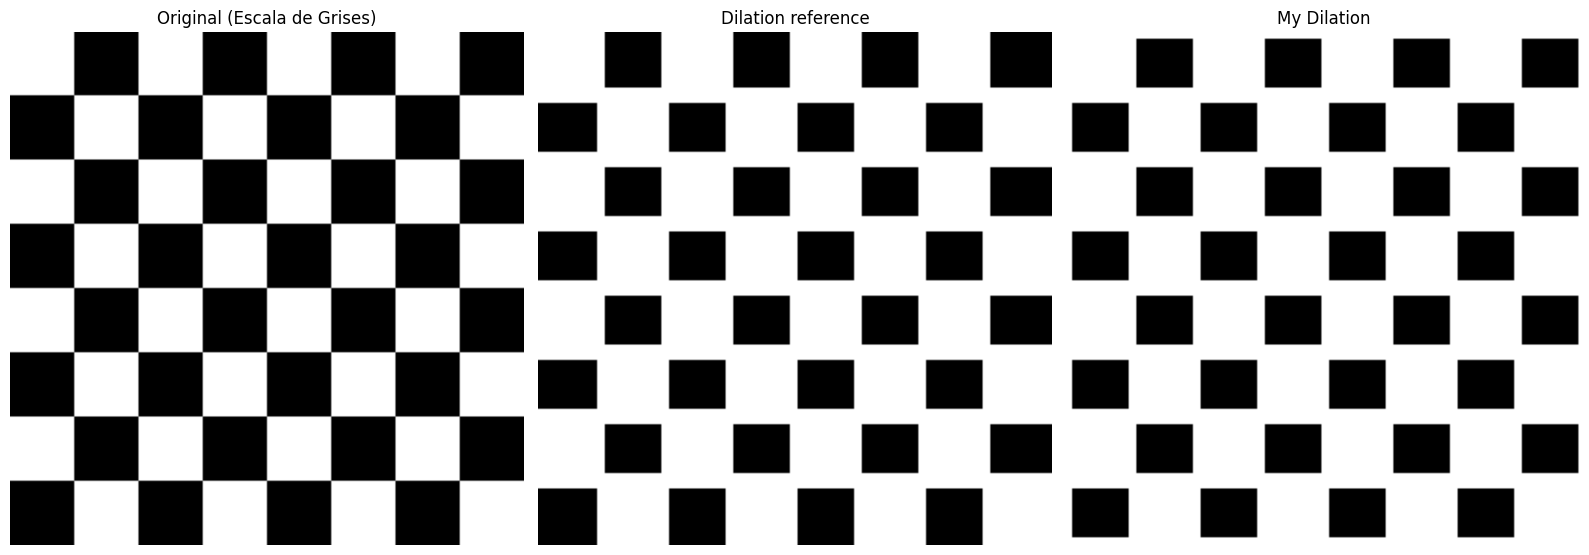

In [59]:
from skimage import data
from skimage import morphology
import matplotlib.pyplot as plt
import numpy as np

def dilation(img,se):
    width, height = img.shape
    se_width, se_height = se.shape
    cx, cy = se_width // 2, se_height // 2 # aproximate center if no point was given for the SE

    print(f'SE: {se_width}x{se_height} -> on ({cx},{cy})')

    # Padding
    pad_top = cx
    pad_bottom = se_width - 1 - cx
    pad_left = cy
    pad_right = se_height - 1 - cy
    
    padded_img = np.pad(img, ((pad_top, pad_bottom), (pad_left, pad_right)), constant_values=1)

    result_img = np.zeros_like(img)
    print(padded_img)

    for x in range(width):
        for y in range(height):
            mask = padded_img[x : x + se_width, y : y + se_height]
            
            # Filtramos solo donde el SE vale 1 y sacamos el mínimo
            masked_img = mask[se == 1]
            
            result_img[x, y] = np.max(masked_img) #basta con que un pixel del SE interseccion la imagen sea 1, osea podemos buscar el maximo
    return result_img


img = data.checkerboard()
img = (img > 128).astype(np.uint8)
#img = np.array([
#    [ 1, 1, 1, 1],
#    [ 1, 1, 1, 1],
#    [ 1, 0, 0, 1],
#    [ 1, 1, 1, 1]
#])

structuring_element = np.array([
    [ 1, 1, 1],
    [ 1, 1, 1],
    [ 1, 1, 1]
])
structuring_element = np.array([
    [ 1, 1, 1, 1],
    [ 1, 0, 0, 1],
    [ 1, 0, 0, 1],
    [ 1, 1, 1, 1],
    [ 1, 1, 1, 1],
    [ 1, 1, 1, 1],
    [ 1, 1, 1, 1],
])

my_dilation = dilation(img,structuring_element)


img_dilation = morphology.dilation(img, structuring_element)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
#
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (Escala de Grises)')
axes[0].axis('off')

axes[1].imshow(img_dilation, cmap='gray')
axes[1].set_title('Dilation reference')
axes[1].axis('off')

axes[2].imshow(my_dilation, cmap='gray')
axes[2].set_title('My Dilation')
axes[2].axis('off')

plt.tight_layout()
plt.show()


In [60]:
from skimage import util, io

# Utilizamos un tipo de dato con mayor precision para no tener problemas en la convolucion
img1 = util.img_as_ubyte(io.imread("./DB1_B/101_1.tif", as_gray=True))
img1 = (img1 > 150).astype(np.uint8)
img2 = util.img_as_ubyte(io.imread("./DB1_B/101_1.tif", as_gray=True))
img2 = (img2 > 150).astype(np.uint8)
img3 = util.img_as_ubyte(io.imread("./DB1_B/101_8.tif", as_gray=True))
img3 = (img3 > 150).astype(np.uint8)

SE: 3x3 -> on (1,1)
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


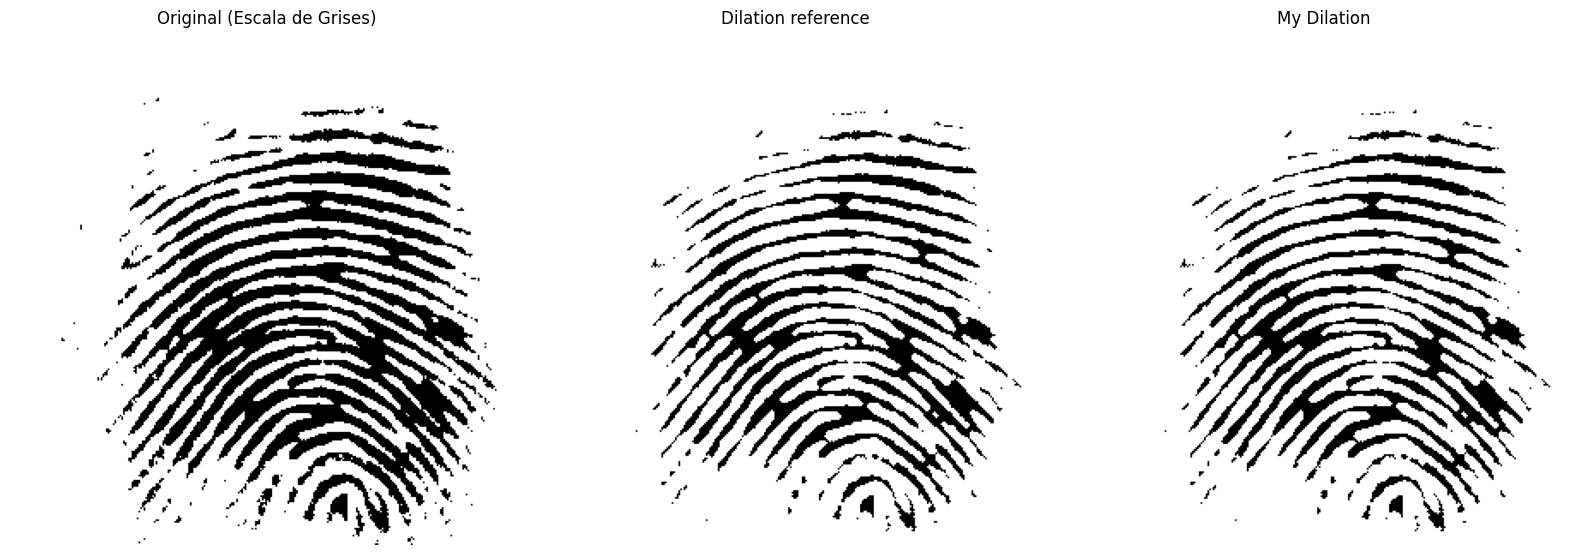

SE: 3x3 -> on (1,1)
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]


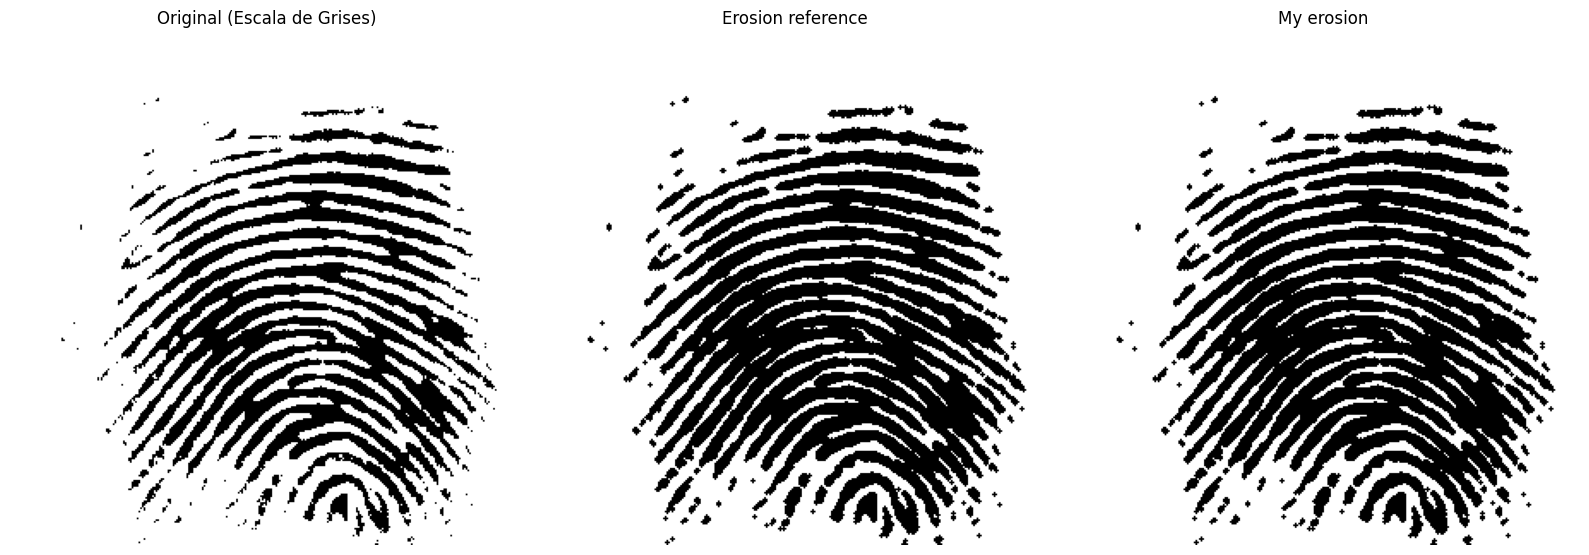

In [61]:
img=img1
structuring_element = np.array([
    [ 0, 1, 0,],
    [ 1, 1, 1,],
    [ 0, 1, 0,],
])

my_dilation = dilation(img,structuring_element)
img_dilation = morphology.dilation(img, structuring_element)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
#
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original (Escala de Grises)')
axes[0].axis('off')

axes[1].imshow(img_dilation, cmap='gray')
axes[1].set_title('Dilation reference')
axes[1].axis('off')

axes[2].imshow(my_dilation, cmap='gray')
axes[2].set_title('My Dilation')
axes[2].axis('off')

plt.tight_layout()
plt.show()

#####
my_erosion = erosion(img,structuring_element)
img_erosion = morphology.erosion(img, structuring_element)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].imshow(img, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Original (Escala de Grises)')
axes[0].axis('off')

axes[1].imshow(img_erosion, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Erosion reference')
axes[1].axis('off')

axes[2].imshow(my_erosion, cmap='gray', vmin=0, vmax=1)
axes[2].set_title('My erosion')
axes[2].axis('off')

plt.tight_layout()
plt.show()
